# A08 — Data Augmentation para imagens ASTER
Data augmentation é uma técnica que amplia artificialmente o conjunto de treinamento por meio de transformações controladas nas imagens, aumentando a variabilidade dos dados e reduzindo overfitting.  
Para imagens ASTER, foram escolhidos rotações, flip, crop e ruído gaussiano para ampliar o conjunto

### Justificativa para transformações aplicadas

Imagens ASTER (Advanced Spaceborne Thermal Emission and Reflection Radiometer) apresentam variabilidade espacial e radiométrica decorrente de diferentes condições de aquisição orbital, geometria de observação e resposta espectral do sensor. Em tarefas de classificação com redes neurais convolucionais, técnicas de *data augmentation* são importantes para ampliar artificialmente a diversidade do conjunto de treinamento, reduzindo overfitting e aumentando a capacidade de generalização do modelo frente a pequenas variações presentes em dados reais.

Entre as transformações selecionadas, a rotação foi aplicada em pequena intensidade para simular variações angulares compatíveis com deslocamentos de aquisição sem comprometer a morfologia espacial dos alvos observados. O flip horizontal foi incluído para aumentar a variabilidade geométrica quando a orientação absoluta não constitui atributo discriminativo da classe analisada. O crop (recorte aleatório seguido de redimensionamento) contribui para robustez espacial ao expor o modelo a diferentes regiões locais da imagem, enquanto a adição de ruído gaussiano simula pequenas perturbações radiométricas associadas ao sensor e às condições atmosféricas.

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
import sys

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

## 1. Carregamento dos dados

In [69]:
repo_root = Path.cwd()
if not (repo_root / 'src').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [70]:
from models.cnn_data_prep import prepare_cnn_inputs

In [71]:
from pathlib import Path
import pandas as pd
import json
import numpy as np

repo_root = Path().resolve().parent

DATASET_PATH = repo_root / 'outputs' / 'pixels_dataset.csv'
CODES_PATH = repo_root / 'data' / 'extracted_codes.json'
NORMALIZER_PATH = repo_root / 'outputs' / 'a04_cnn_data_prep' / 'cnn_normalizer_zscore.npz'

print("Carregando dataset de pixels...")

df = pd.read_csv(DATASET_PATH)

Carregando dataset de pixels...


### Preparação das entradas para CNN

A função `prepare_cnn_inputs` organiza os dados no formato esperado pela rede convolucional, preservando a estrutura espacial das imagens ASTER e removendo amostras com rótulos inválidos.

In [72]:
probe = prepare_cnn_inputs(
    df,
    extracted_codes_path=CODES_PATH,
    normalization='none',
    data_format='channels_last',
    drop_invalid_labels=False,
)

X = probe['X']
y = probe['y']

valid_mask = y != -1
X = X[valid_mask]
y = y[valid_mask]

normalizer = np.load(NORMALIZER_PATH)
mean = normalizer['mean']
std = normalizer['std']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (295, 128, 128, 9)
Shape y: (295,)


## 2. Pipeline de augmentation

- **Rotação leve (±15°)** → preserva orientação orbital sem distorção extrema  
- **Flip horizontal** → útil quando classe não depende de direção absoluta  
- **Random crop** → aumenta invariância espacial  
- **Ruído gaussiano leve** → simula variação radiométrica


In [73]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.08),      # ~ ±15°
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomCrop(120, 120),
    tf.keras.layers.Resizing(128, 128),
    tf.keras.layers.GaussianNoise(0.02)
])

## 3. Aplicação em amostra visual

In [74]:
import tensorflow as tf
import matplotlib.pyplot as plt

sample = X[0:1].astype(np.float32)

rgb_bands = [0, 1, 2]

# cada transformação isolada
augmented = [
    tf.keras.layers.RandomRotation(0.08)(sample, training=True)[0].numpy(),
    tf.keras.layers.RandomFlip("horizontal")(sample, training=True)[0].numpy(),
    tf.keras.Sequential([
        tf.keras.layers.RandomCrop(120, 120),
        tf.keras.layers.Resizing(128, 128)
    ])(sample, training=True)[0].numpy(),
    tf.keras.layers.GaussianNoise(0.02)(sample, training=True)[0].numpy()
]

labels = [
    "Aug 1 (Rotação)",
    "Aug 2 (Flip)",
    "Aug 3 (Crop)",
    "Aug 4 (Ruído)"
]

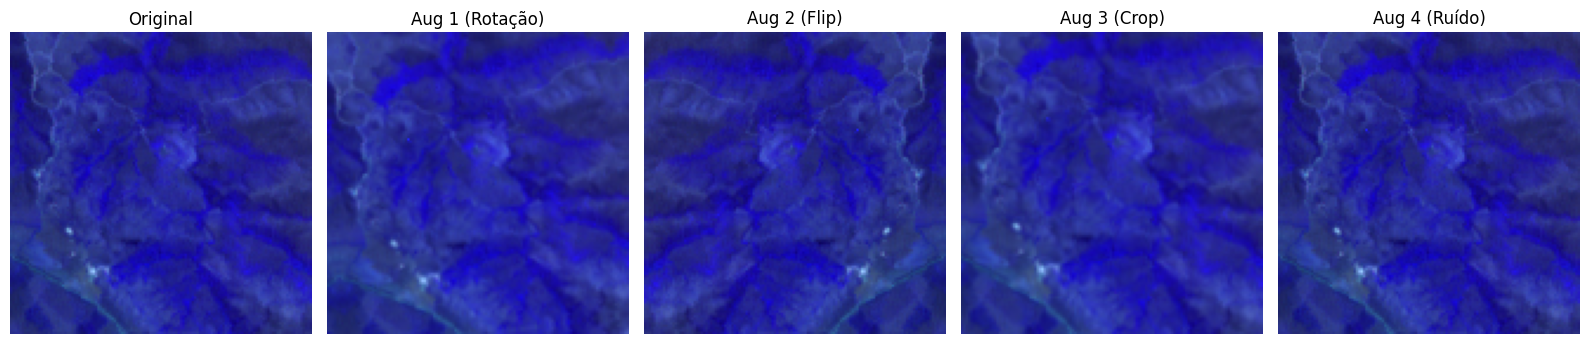

In [75]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

# original
orig = sample[0][:, :, rgb_bands]
orig = (orig - orig.min()) / (orig.max() - orig.min() + 1e-8)

axes[0].imshow(orig)
axes[0].set_title("Original")
axes[0].axis("off")

# augmentações
for i, img in enumerate(augmented):
    vis = img[:, :, rgb_bands]
    vis = (vis - vis.min()) / (vis.max() - vis.min() + 1e-8)

    axes[i+1].imshow(vis)
    axes[i+1].set_title(labels[i])
    axes[i+1].axis("off")

plt.tight_layout()
plt.show()

## Integração com `tf.data`

A API `tf.data` permite construir pipelines eficientes de entrada de dados no TensorFlow, organizando carregamento, batching e transformações de forma automática durante o treinamento. Nesse contexto, o data augmentation pode ser aplicado dinamicamente a cada lote de imagens, fazendo com que novas variações sejam geradas a cada época sem modificar permanentemente o conjunto original.

In [76]:
dataset = tf.data.Dataset.from_tensor_slices(X)

train_ds = (
    dataset
    .shuffle(len(X))
    .batch(4)
    .map(lambda x: augmentation(x, training=True))
    .prefetch(tf.data.AUTOTUNE)
)

for batch in train_ds.take(1):
    print("Batch shape:", batch.shape)

Batch shape: (4, 128, 128, 9)


## Conclusão

A aplicação de técnicas de data augmentation em imagens ASTER permite ampliar artificialmente a variabilidade do conjunto de treinamento sem alterar a natureza dos dados originais, contribuindo para reduzir overfitting e melhorar a capacidade de generalização de modelos convolucionais. As transformações selecionadas foram definidas de forma controlada para preservar características espaciais e espectrais relevantes, evitando distorções excessivas que poderiam comprometer a interpretação dos padrões presentes nas imagens.

A utilização de rotação, flip, crop e ruído gaussiano introduz variações geométricas e radiométricas compatíveis com situações plausíveis de aquisição em sensoriamento remoto. Além disso, a integração dessas transformações ao pipeline de treino com `tf.data` garante que apenas o conjunto de treinamento seja modificado, mantendo validação e teste consistentes para avaliação experimental confiável.